In [ ]:
# Convolutional Neural Network

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the Dataset
train_data = pd.read_csv("../data/train.csv")

print("Training data shape:", train_data.shape)
print(train_data.head())

Training data shape: (42000, 785)
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel78

In [3]:
# Separate features and labels

X = train_data.drop("label", axis=1)
y = train_data["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (42000, 784)
y shape: (42000,)


In [4]:
# Normalize the pixel values
X = X / 255.0

print("Minimum pixel value:", X.min().min())
print("Maximum pixel value:", X.max().max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [5]:
# Split the dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (33600, 784)
X_test: (8400, 784)
y_train: (33600,)
y_test: (8400,)


In [6]:
# Reshape the images for CNN

X_train_cnn = X_train.values.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.values.reshape(-1, 28, 28, 1)

print("CNN training data:", X_train_cnn.shape)
print("CNN testing data:", X_test_cnn.shape)

CNN training data: (33600, 28, 28, 1)
CNN testing data: (8400, 28, 28, 1)


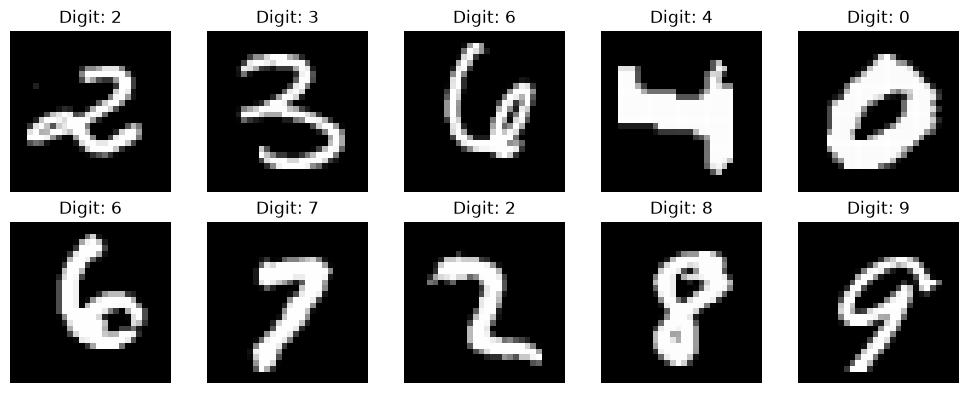

In [7]:
# Check the reshaped images

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train_cnn[i].reshape(28, 28), cmap="gray")
    plt.title(f"Digit: {y_train.iloc[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Import TensorFlow/Keras

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input,Conv2D,MaxPooling2D,Flatten,Dense,Dropout)

# Build the CNN model

cnn = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(10, activation="softmax")
])

In [9]:
# View the CNN architecture

cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the CNN

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
# Train the CNN

history = cnn.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.8884 - loss: 0.3635 - val_accuracy: 0.9762 - val_loss: 0.0792
Epoch 2/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9678 - loss: 0.1138 - val_accuracy: 0.9786 - val_loss: 0.0650
Epoch 3/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9748 - loss: 0.0840 - val_accuracy: 0.9833 - val_loss: 0.0595
Epoch 4/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 0.9805 - loss: 0.0662 - val_accuracy: 0.9854 - val_loss: 0.0470
Epoch 5/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.9829 - loss: 0.0538 - val_accuracy: 0.9863 - val_loss: 0.0477
Epoch 6/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.9845 - loss: 0.0490 - val_accuracy: 0.9857 - val_loss: 0.0445
Epoch 7/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.9870 - loss: 0.0403 - val_accuracy: 0.9863 - val_loss: 0.0462
Epoch 8/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.9874 - loss: 0.0363 - 

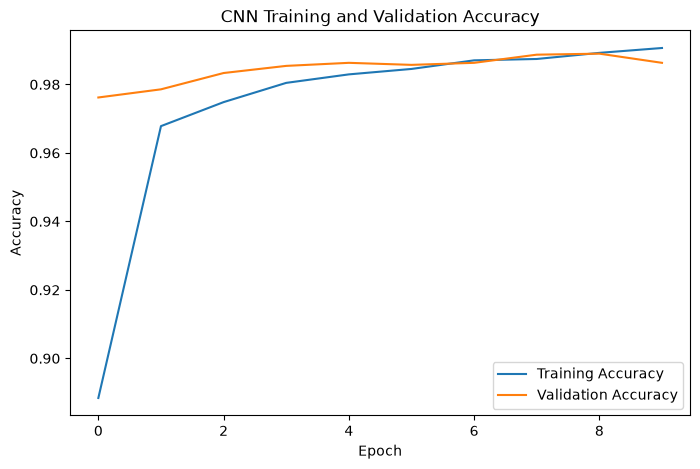

In [12]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.show()

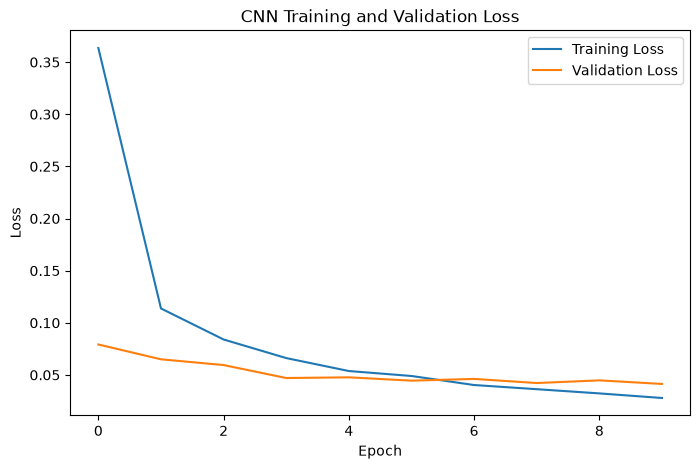

In [13]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.show()

In [14]:
# Evaluate CNN on the test data

test_loss, test_accuracy = cnn.evaluate(
    X_test_cnn,
    y_test,
    verbose=1
)

print("CNN Test Loss:", test_loss)
print("CNN Test Accuracy:", test_accuracy)
print("CNN Test Accuracy (%):", test_accuracy * 100)

263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9890 - loss: 0.0395
CNN Test Loss: 0.03954532369971275
CNN Test Accuracy: 0.989047646522522
CNN Test Accuracy (%): 98.9047646522522


In [17]:
# Generate CNN predictions

y_pred_prob = cnn.predict(X_test_cnn)

# Convert probabilities to predicted digit
y_pred_cnn = np.argmax(y_pred_prob, axis=1)

print("First 10 predictions:", y_pred_cnn[:10])

263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
First 10 predictions: [1 8 6 9 5 7 6 7 7 7]


In [18]:
# Calculate Accuracy, Precision, Recall and F1-score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

cnn_accuracy = accuracy_score(y_test, y_pred_cnn)

cnn_precision = precision_score(
    y_test,
    y_pred_cnn,
    average="weighted"
)

cnn_recall = recall_score(
    y_test,
    y_pred_cnn,
    average="weighted"
)

cnn_f1 = f1_score(
    y_test,
    y_pred_cnn,
    average="weighted"
)

print("CNN Accuracy :", cnn_accuracy)
print("CNN Accuracy (%):", cnn_accuracy * 100)

print("CNN Precision:", cnn_precision)
print("CNN Precision (%):", cnn_precision * 100)

print("CNN Recall   :", cnn_recall)
print("CNN Recall (%):", cnn_recall * 100)

print("CNN F1-Score :", cnn_f1)
print("CNN F1-Score (%):", cnn_f1 * 100)

CNN Accuracy : 0.9890476190476191
CNN Accuracy (%): 98.90476190476191
CNN Precision: 0.9891036689657405
CNN Precision (%): 98.91036689657405
CNN Recall   : 0.9890476190476191
CNN Recall (%): 98.90476190476191
CNN F1-Score : 0.9890546513329188
CNN F1-Score (%): 98.90546513329188


In [19]:
# Calculate the CNN error rate

cnn_error_rate = 1 - cnn_accuracy

print("CNN Error Rate:", cnn_error_rate)
print("CNN Error Rate (%):", cnn_error_rate * 100)

CNN Error Rate: 0.010952380952380936
CNN Error Rate (%): 1.0952380952380936


In [20]:
# Find correct and incorrect predictions

correct = (y_test.values == y_pred_cnn).sum()
incorrect = (y_test.values != y_pred_cnn).sum()

print("Correct predictions:", correct)
print("Incorrect predictions:", incorrect)
print("Total predictions:", len(y_test))

Correct predictions: 8308
Incorrect predictions: 92
Total predictions: 8400


In [21]:
# Classification report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_cnn))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       827
           1       1.00      0.99      1.00       937
           2       0.99      0.99      0.99       835
           3       0.99      0.99      0.99       870
           4       0.99      1.00      0.99       814
           5       0.99      0.98      0.99       759
           6       0.99      1.00      0.99       827
           7       0.99      0.99      0.99       880
           8       0.99      0.98      0.98       813
           9       0.97      0.99      0.98       838

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.99      0.99      0.99      8400



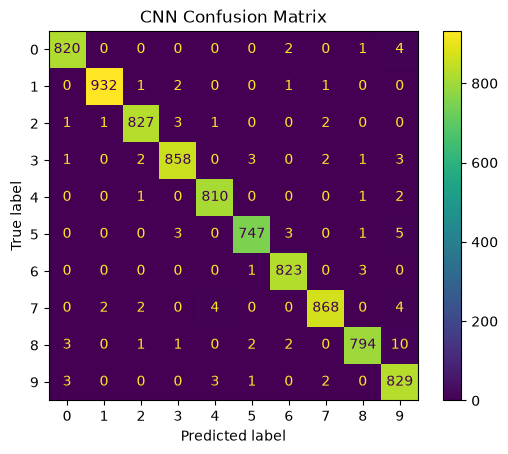

In [22]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_cnn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot()
plt.title("CNN Confusion Matrix")
plt.show()

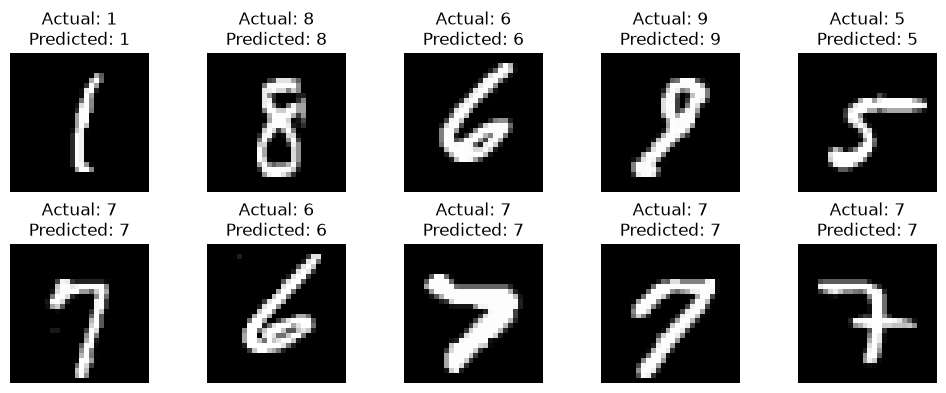

In [23]:
# Display some predictions

plt.figure(figsize=(10, 4))

for i in range(10):
    image = X_test_cnn[i].reshape(28, 28)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"Actual: {y_test.iloc[i]}\nPredicted: {y_pred_cnn[i]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

Number of incorrect predictions: 92


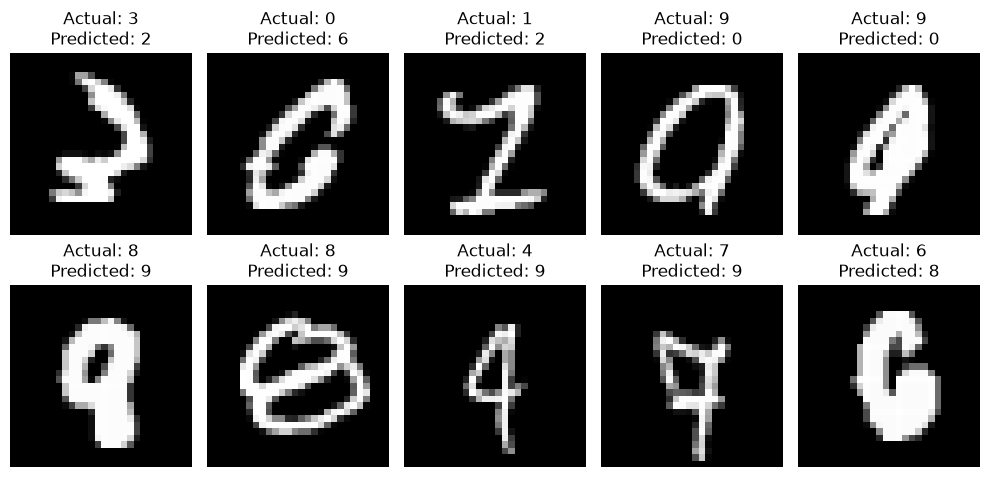

In [24]:
# Display incorrect predictions

wrong_indices = np.where(
    y_test.values != y_pred_cnn
)[0]

print("Number of incorrect predictions:", len(wrong_indices))

plt.figure(figsize=(10, 5))

for j, i in enumerate(wrong_indices[:10]):
    image = X_test_cnn[i].reshape(28, 28)

    plt.subplot(2, 5, j + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"Actual: {y_test.iloc[i]}\nPredicted: {y_pred_cnn[i]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
# Save the CNN model

cnn.save("cnn_digit_model.keras")

print("CNN model saved successfully!")

CNN model saved successfully!


In [26]:
#                     TRAIN.CSV
#                        ↓
#               Load the dataset
#                        ↓
#              Separate X and y
#                        ↓
#               Normalize pixels
#                  (0 → 1)
#                        ↓
#              Train/Test Split
#                        ↓
#           ┌────────────┴────────────┐
#           ↓                         ↓
#      X_train, y_train          X_test, y_test
#           ↓                         ↓
#     Reshape training            Reshape testing
#      images to                   images to
#     28 × 28 × 1                 28 × 28 × 1
#           ↓
#        Build CNN
#           ↓
#        Conv2D
#           ↓
#     MaxPooling2D
#           ↓
#        Conv2D
#           ↓
#     MaxPooling2D
#           ↓
#        Flatten
#           ↓
#     Dense Layer
#           ↓
#       Dropout
#           ↓
#     Dense(10)
#           ↓
#       Compile CNN
#           ↓
#       Train CNN
#           ↓
#      cnn.fit()
#           ↓
#     Trained CNN Model
#           ↓
#     cnn.predict()
#           ↓
#       y_pred_prob
#           ↓
#       np.argmax()
#           ↓
#       y_pred_cnn
#           ↓
#  ┌────────┼─────────┬─────────┐
#  ↓        ↓         ↓         ↓
# Accuracy Precision Recall   F1-Score
#  ↓        ↓         ↓         ↓
#  └────────┴─────────┴─────────┘
#               ↓
#          Error Rate
#               ↓
#       Confusion Matrix
#               ↓
#      Incorrect Predictions
#               ↓
#         Save CNN Model